THỬ NGHIỆM: 24-PUZZLE (5x5, n=5)

Trạng thái ban đầu:
(1, 2, 8, 10, 3)
(6, 7, 4, 9, 5)
(11, 12, 13, 14, 0)
(16, 17, 24, 19, 15)
(21, 22, 18, 23, 20)

Trạng thái đích:
(1, 2, 3, 4, 5)
(6, 7, 8, 9, 10)
(11, 12, 13, 14, 15)
(16, 17, 18, 19, 20)
(21, 22, 23, 24, 0)

Heuristic ban đầu (Manhattan + Linear Conflict): 14


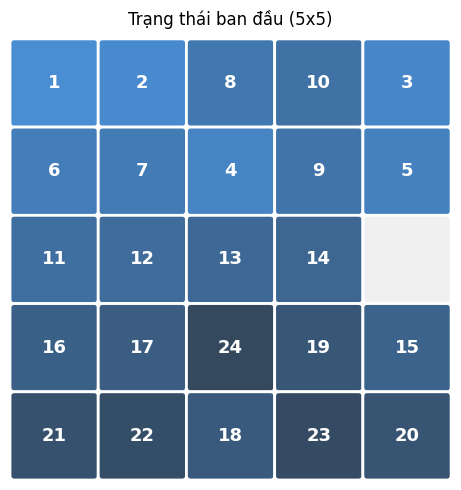

    Số bước: 20
    Số nút đã duyệt: 162
    Thời gian: 0.0194 giây

Chuỗi di chuyển:
LEFT → UP → UP → RIGHT → DOWN → LEFT → LEFT → UP → RIGHT → DOWN → DOWN → RIGHT → DOWN → LEFT → LEFT → DOWN → RIGHT → UP → RIGHT → DOWN


In [7]:
#Bài 1. Cài đặt thuật giải AKT vào bài toán 15 puzzle(n=4).
import heapq
import random
import time
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import clear_output

class PuzzleState:
    def __init__(self, board, n, parent=None, move=None, g=0):
        """
        board: tuple of tuples (trạng thái bảng)
        n    : kích thước (n x n)
        parent: trạng thái cha
        move : hướng di chuyển tạo ra trạng thái này
        g    : chi phí đã đi
        """
        self.board = board
        self.n = n
        self.parent = parent
        self.move = move
        self.g = g
        self.h = self.heuristic()
        self.f = self.g + self.h

    def find_blank(self):
        """Tìm vị trí ô trống (0)"""
        for i in range(self.n):
            for j in range(self.n):
                if self.board[i][j] == 0:
                    return i, j

    def manhattan_distance(self):
        """Tính tổng khoảng cách Manhattan"""
        dist = 0
        for i in range(self.n):
            for j in range(self.n):
                val = self.board[i][j]
                if val != 0:
                    # Vị trí đích của val
                    goal_r = (val - 1) // self.n
                    goal_c = (val - 1) % self.n
                    dist += abs(i - goal_r) + abs(j - goal_c)
        return dist

    def linear_conflict(self):
        """Linear Conflict heuristic (cải tiến Manhattan)"""
        conflict = 0

        # Xung đột theo hàng
        for row in range(self.n):
            for c1 in range(self.n):
                val1 = self.board[row][c1]
                if val1 == 0: continue
                goal_r1 = (val1 - 1) // self.n
                if goal_r1 != row: continue
                for c2 in range(c1 + 1, self.n):
                    val2 = self.board[row][c2]
                    if val2 == 0: continue
                    goal_r2 = (val2 - 1) // self.n
                    if goal_r2 != row: continue
                    goal_c1 = (val1 - 1) % self.n
                    goal_c2 = (val2 - 1) % self.n
                    if goal_c1 > goal_c2:
                        conflict += 2
        # Xung đột theo cột
        for col in range(self.n):
            for r1 in range(self.n):
                val1 = self.board[r1][col]
                if val1 == 0: continue
                goal_c1 = (val1 - 1) % self.n
                if goal_c1 != col: continue
                for r2 in range(r1 + 1, self.n):
                    val2 = self.board[r2][col]
                    if val2 == 0: continue
                    goal_c2 = (val2 - 1) % self.n
                    if goal_c2 != col: continue
                    goal_r1 = (val1 - 1) // self.n
                    goal_r2 = (val2 - 1) // self.n
                    if goal_r1 > goal_r2:
                        conflict += 2

        return conflict

    def heuristic(self):
        """Heuristic kết hợp: Manhattan + Linear Conflict"""
        return self.manhattan_distance() + self.linear_conflict()

    def get_neighbors(self):
        """Sinh các trạng thái kế tiếp (lân cận)"""
        neighbors = []
        r, c = self.find_blank()
        directions = {
            'UP':    (-1, 0),
            'DOWN':  ( 1, 0),
            'LEFT':  ( 0,-1),
            'RIGHT': ( 0, 1)
        }
        for move, (dr, dc) in directions.items():
            nr, nc = r + dr, c + dc
            if 0 <= nr < self.n and 0 <= nc < self.n:
                # Tạo bảng mới
                new_board = [list(row) for row in self.board]
                new_board[r][c], new_board[nr][nc] = new_board[nr][nc], new_board[r][c]
                new_board_tuple = tuple(tuple(row) for row in new_board)
                neighbors.append(PuzzleState(new_board_tuple, self.n, self, move, self.g + 1))

        return neighbors

    def is_goal(self):
        """Kiểm tra trạng thái đích"""
        goal = list(range(1, self.n * self.n)) + [0]
        flat = [self.board[i][j] for i in range(self.n) for j in range(self.n)]
        return flat == goal

    def __lt__(self, other):
        return self.f < other.f

    def __eq__(self, other):
        return self.board == other.board

    def __hash__(self):
        return hash(self.board)
# ============================================================
# THUẬT GIẢI A* (AKT)
# ============================================================
def a_star_puzzle(initial_state):
    """
    Thuật giải A* cho n²-1 Puzzle
    Trả về: (đường đi, số nút đã duyệt, thời gian)
    """
    start_time = time.time()

    # Hàng đợi ưu tiên (min-heap)
    open_list = []
    heapq.heappush(open_list, (initial_state.f, initial_state))

    # Tập đã duyệt
    closed_set = set()

    # Đếm số nút
    nodes_explored = 0

    while open_list:
        _, current = heapq.heappop(open_list)

        if current.board in closed_set:
            continue

        closed_set.add(current.board)
        nodes_explored += 1
        # Kiểm tra đích
        if current.is_goal():
            elapsed = time.time() - start_time
            path = []
            state = current
            while state:
                path.append(state)
                state = state.parent
            path.reverse()
            return path, nodes_explored, elapsed

        # Sinh các trạng thái kế tiếp
        for neighbor in current.get_neighbors():
            if neighbor.board not in closed_set:
                heapq.heappush(open_list, (neighbor.f, neighbor))

    return None, nodes_explored, time.time() - start_time

def is_solvable(board, n):
    """Kiểm tra bài toán có giải được không"""
    flat = [board[i][j] for i in range(n) for j in range(n) if board[i][j] != 0]
    inversions = 0
    for i in range(len(flat)):
        for j in range(i + 1, len(flat)):
            if flat[i] > flat[j]:
                inversions += 1

    # Tìm hàng của ô trống (tính từ dưới lên)
    blank_row = 0
    for i in range(n):
        for j in range(n):
            if board[i][j] == 0:
                blank_row = n - i  # tính từ dưới

    if n % 2 == 1:
        return inversions % 2 == 0
    else:
        if blank_row % 2 == 0:
            return inversions % 2 == 1
        else:
            return inversions % 2 == 0
def generate_random_puzzle(n, shuffle_steps=30):
    """Tạo puzzle ngẫu nhiên giải được bằng cách shuffle từ trạng thái đích"""
    # Bắt đầu từ trạng thái đích
    goal = list(range(1, n*n)) + [0]
    board = [goal[i*n:(i+1)*n] for i in range(n)]

    r, c = n-1, n-1  # vị trí ô trống
    directions = [(-1,0),(1,0),(0,-1),(0,1)]

    prev_move = None
    for _ in range(shuffle_steps):
        moves = []
        for dr, dc in directions:
            nr, nc = r+dr, c+dc
            if 0 <= nr < n and 0 <= nc < n:
                if (dr, dc) != prev_move:
                    moves.append((dr, dc))
        dr, dc = random.choice(moves)
        nr, nc = r+dr, c+dc
        board[r][c], board[nr][nc] = board[nr][nc], board[r][c]
        prev_move = (-dr, -dc)  # ngăn quay lại
        r, c = nr, nc

    return tuple(tuple(row) for row in board)
def visualize_board(board, n, title='', ax=None, show=True):
    """Hiển thị bảng puzzle"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(n, n))

    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_aspect('equal')
    ax.axis('off')

    colors = {'blank': '#f0f0f0', 'tile': '#4A90D9', 'text': 'white'}

    for i in range(n):
        for j in range(n):
            val = board[i][j]
            x, y = j, n - 1 - i
            if val == 0:
                color = colors['blank']
                text_color = 'gray'
                text = ''
            else:
                # Màu gradient theo giá trị
                ratio = val / (n*n - 1)
                r_val = int(74 + ratio * (52 - 74))
                g_val = int(144 + ratio * (73 - 144))
                b_val = int(217 + ratio * (94 - 217))
                color = f'#{r_val:02x}{g_val:02x}{b_val:02x}'
                text_color = 'white'
                text = str(val)

            rect = patches.FancyBboxPatch(
                (x + 0.05, y + 0.05), 0.9, 0.9,
                boxstyle='round,pad=0.05',
                facecolor=color, edgecolor='white', linewidth=2
            )
            ax.add_patch(rect)

            if text:
                fontsize = max(8, 18 - n)
                ax.text(x + 0.5, y + 0.5, text,
                        ha='center', va='center',
                        fontsize=fontsize, fontweight='bold',
                        color=text_color)

    if title:
        ax.set_title(title, fontsize=12, pad=10)

    if show:
        plt.tight_layout()
        plt.show()
def visualize_solution(path, n, max_display=10):
    """Hiển thị các bước giải"""
    steps = path
    if len(path) > max_display:
        # Lấy đều các bước
        indices = list(range(0, len(path), len(path) // max_display))[:max_display]
        indices[-1] = len(path) - 1
        steps = [path[i] for i in indices]

    cols = min(5, len(steps))
    rows = (len(steps) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * (n+0.5), rows * (n+0.5)))

    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]

    step_idx = 0
    for r in range(rows):
        for c in range(cols):
            ax = axes[r][c]
            if step_idx < len(steps):
                state = steps[step_idx]
                move_label = state.move if state.move else 'Start'
                title = f'Bước {state.g}\n({move_label})'
                visualize_board(state.board, n, title=title, ax=ax, show=False)
            else:
                ax.axis('off')
            step_idx += 1
    plt.suptitle(f'Giải n²-1 Puzzle (n={n}) - Tổng {len(path)-1} bước', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
# ============================================================
# CHẠY THỬ: n = 5 (24-PUZZLE)
# ============================================================
print('='*60)
print('THỬ NGHIỆM: 24-PUZZLE (5x5, n=5)')
print('='*60)

n = 5
random.seed(42)
board = generate_random_puzzle(n, shuffle_steps=20)

print('\nTrạng thái ban đầu:')
for row in board:
    print(row)

goal_board = tuple(tuple(range(i*n+1, (i+1)*n+1)) for i in range(n))
goal_board_list = list(goal_board)
last_row = list(goal_board_list[-1])
last_row[-1] = 0
last_row[-2] = n*n
# Chuẩn trạng thái đích
goal_flat = list(range(1, n*n)) + [0]
print('\nTrạng thái đích:')
for i in range(n):
    print(tuple(goal_flat[i*n:(i+1)*n]))
# Tạo trạng thái ban đầu
initial = PuzzleState(board, n)
print(f'\nHeuristic ban đầu (Manhattan + Linear Conflict): {initial.h}')

# Hiển thị trạng thái ban đầu
plt.figure(figsize=(5, 5))
ax = plt.gca()
visualize_board(board, n, title=f'Trạng thái ban đầu ({n}x{n})', ax=ax, show=False)
plt.tight_layout()
plt.show()

# Chạy A*
path, nodes, elapsed = a_star_puzzle(initial)

if path:
    print(f'    Số bước: {len(path)-1}')
    print(f'    Số nút đã duyệt: {nodes}')
    print(f'    Thời gian: {elapsed:.4f} giây')
    print(f'\nChuỗi di chuyển:')
    moves = [s.move for s in path if s.move]
    print(' → '.join(moves))
else:
    print('❌ Không tìm được lời giải!')

In [3]:
import heapq
import math
import random
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Missing function: generate_cities
def generate_cities(num_cities, x_lim=(0, 100), y_lim=(0, 100), seed=None):
    if seed is not None:
        random.seed(seed)
    return [(random.uniform(*x_lim), random.uniform(*y_lim)) for _ in range(num_cities)]

def euclidean_dist(p1, p2):
    """Khoảng cách Euclidean giữa 2 điểm"""
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)


def build_distance_matrix(cities):
    """Xây dựng ma trận khoảng cách"""
    n = len(cities)
    dist = [[0.0]*n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            dist[i][j] = euclidean_dist(cities[i], cities[j])
    return dist

def mst_cost(nodes, dist_matrix):
    """
    Tính chi phí MST của tập nút 'nodes' dùng thuật Prim.
    Đây là cận dưới admissible cho chi phí còn lại.
    """
    if len(nodes) <= 1:
        return 0
    nodes = list(nodes) # Corrected indentation
    visited = {nodes[0]}
    total_cost = 0
    min_heap = []

    # Thêm cạnh từ nút đầu tiên
    for v in nodes[1:]:
        heapq.heappush(min_heap, (dist_matrix[nodes[0]][v], v))

    while len(visited) < len(nodes):
        cost, u = heapq.heappop(min_heap)
        if u in visited:
            continue
        visited.add(u)
        total_cost += cost
        for v in nodes:
            if v not in visited:
                heapq.heappush(min_heap, (dist_matrix[u][v], v))

    return total_cost
def heuristic_tsp(current_city, unvisited, start_city, dist_matrix):
    """
    Heuristic cho TSP A*:
    h = MST(unvisited ∪ {current, start})
    + min edge từ current đến unvisited
    + min edge từ unvisited đến start
    """
    if not unvisited:
        return dist_matrix[current_city][start_city]

    # Nút trong MST = các thành phố chưa thăm + điểm đầu (để quay về)
    mst_nodes = set(unvisited) | {start_city}
    mst_val = mst_cost(mst_nodes, dist_matrix)

    # Chi phí tối thiểu từ current đến unvisited
    min_to_unvisited = min(dist_matrix[current_city][u] for u in unvisited)

    return mst_val + min_to_unvisited
class TSPState:
    def __init__(self, path, unvisited, g, h):
        """
        path     : tuple các thành phố đã thăm (theo thứ tự)
        unvisited: frozenset các thành phố chưa thăm
        g        : chi phí đã đi
        h        : ước lượng chi phí còn lại
        """
        self.path = path
        self.unvisited = unvisited
        self.g = g
        self.h = h
        self.f = g + h

    def __lt__(self, other):
        return self.f < other.f

# ============================================================
# THUẬT GIẢI A* CHO TSP
# ============================================================
def a_star_tsp(num_cities, dist_matrix, start=0):
    """
    A* cho TSP
    Trả về: (đường đi tối ưu, chi phí, số nút duyệt, thời gian)
    """
    start_time = time.time()
    all_cities = set(range(num_cities))

    # Trạng thái ban đầu
    init_unvisited = frozenset(all_cities - {start})
    init_h = heuristic_tsp(start, init_unvisited, start, dist_matrix)
    init_state = TSPState((start,), init_unvisited, 0, init_h)

    # Priority queue
    open_list = [(init_state.f, init_state)]
    visited_states = {}  # (last_city, unvisited) -> best_g

    nodes_explored = 0
    best_solution = None
    best_cost = float('inf')

    while open_list:
        _, state = heapq.heappop(open_list)

        current = state.path[-1]
        state_key = (current, state.unvisited)

        # Pruning: nếu đã tìm được trạng thái này với chi phí thấp hơn
        if state_key in visited_states and visited_states[state_key] <= state.g:
            continue
        visited_states[state_key] = state.g

        nodes_explored += 1
        # Pruning theo bound
        if state.f >= best_cost:
            continue

        # Kiểm tra đích: đã thăm hết, quay về start
        if not state.unvisited:
            total_cost = state.g + dist_matrix[current][start]
            if total_cost < best_cost:
                best_cost = total_cost
                best_solution = state.path + (start,)
            continue

        # Sinh các thành phố tiếp theo
        for next_city in state.unvisited:
            new_g = state.g + dist_matrix[current][next_city]
            if new_g >= best_cost:
                continue

            new_unvisited = state.unvisited - {next_city}
            new_h = heuristic_tsp(next_city, new_unvisited, start, dist_matrix)
            new_state = TSPState(
                state.path + (next_city,),
                new_unvisited,
                new_g,
                new_h
            )
            heapq.heappush(open_list, (new_state.f, new_state))

    elapsed = time.time() - start_time
    return best_solution, best_cost, nodes_explored, elapsed

# ============================================================
# THUẬT GIẢI THAM LIAM (GREEDY) ĐỂ SO SÁNH
# ============================================================
def greedy_tsp(num_cities, dist_matrix, start=0):
    """Thuật giải tham lam: luôn đến thành phố gần nhất"""
    visited = [False] * num_cities
    path = [start]
    visited[start] = True
    total_cost = 0

    for _ in range(num_cities - 1):
        current = path[-1]
        nearest = -1
        min_dist = float('inf')
        for j in range(num_cities):
            if not visited[j] and dist_matrix[current][j] < min_dist:
                min_dist = dist_matrix[current][j]
                nearest = j
        path.append(nearest)
        visited[nearest] = True
        total_cost += min_dist

    total_cost += dist_matrix[path[-1]][start]
    path.append(start)
    return tuple(path), total_cost

def visualize_tsp(cities, path, title='', cost=0, color='#4A90D9', ax=None, show=True):
    """Hiển thị đường đi TSP"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 7))

    n = len(cities)
    xs = [c[0] for c in cities]
    ys = [c[1] for c in cities]

    # Vẽ đường đi
    if path:
        path_xs = [cities[p][0] for p in path]
        path_ys = [cities[p][1] for p in path]
        ax.plot(path_xs, path_ys, '-', color=color, linewidth=2, alpha=0.7, zorder=1)

        # Vẽ mũi tên hướng
        for i in range(len(path)-1):
            x1, y1 = cities[path[i]]
            x2, y2 = cities[path[i+1]]
            mx, my = (x1+x2)/2, (y1+y2)/2
            dx, dy = x2-x1, y2-y1
            ax.annotate('', xy=(mx+dx*0.01, my+dy*0.01),
                        xytext=(mx-dx*0.01, my-dy*0.01),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
                        zorder=2)
# Vẽ các điểm
    for i, (x, y) in enumerate(cities):
        if i == 0:  # Điểm xuất phát (kho)
            ax.scatter(x, y, s=200, c='#E74C3C', zorder=5, marker='*')
            ax.annotate(f' Kho (0)', (x, y), fontsize=9,
                        fontweight='bold', color='#E74C3C',
                        xytext=(5, 5), textcoords='offset points')
        else:
            ax.scatter(x, y, s=100, c='#2C3E50', zorder=5)
            ax.annotate(f' {i}', (x, y), fontsize=8, color='#2C3E50',
                        xytext=(5, 3), textcoords='offset points')

    ax.set_title(f'{title}\nChi phí: {cost:.2f}', fontsize=12, fontweight='bold')
    ax.set_facecolor('#f8f9fa')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

    if show:
        plt.tight_layout()
        plt.show()

# Main execution block - Corrected indentation and removed from visualize_tsp
print('='*60)
print('THỬ NGHIỆM: 10 THÀNH PHỐ')
print('='*60)

NUM_CITIES = 10
cities = generate_cities(NUM_CITIES, seed=42)
dist_matrix = build_distance_matrix(cities)

print(f'Số thành phố: {NUM_CITIES}')
print('Tọa độ các thành phố:')
for i, (x, y) in enumerate(cities):
    label = '(Kho)' if i == 0 else ''
    print(f'  Thành phố {i}: ({x:.2f}, {y:.2f}) {label}')

# Chạy A*
path_astar, cost_astar, nodes_astar, time_astar = a_star_tsp(NUM_CITIES, dist_matrix, start=0)

# Chạy Greedy
path_greedy, cost_greedy = greedy_tsp(NUM_CITIES, dist_matrix, start=0)

print(f'\n📊 KẾT QUẢ:')
print(f'─'*40)
print(f'Thuật giải A*:')
print(f'  Đường đi: {" → ".join(str(p) for p in path_astar)}')
print(f'  Chi phí: {cost_astar:.4f}')
print(f'  Số nút duyệt: {nodes_astar}')
print(f'  Thời gian: {time_astar:.4f}s')


THỬ NGHIỆM: 10 THÀNH PHỐ
Số thành phố: 10
Tọa độ các thành phố:
  Thành phố 0: (63.94, 2.50) (Kho)
  Thành phố 1: (27.50, 22.32) 
  Thành phố 2: (73.65, 67.67) 
  Thành phố 3: (89.22, 8.69) 
  Thành phố 4: (42.19, 2.98) 
  Thành phố 5: (21.86, 50.54) 
  Thành phố 6: (2.65, 19.88) 
  Thành phố 7: (64.99, 54.49) 
  Thành phố 8: (22.04, 58.93) 
  Thành phố 9: (80.94, 0.65) 

📊 KẾT QUẢ:
────────────────────────────────────────
Thuật giải A*:
  Đường đi: 0 → 9 → 3 → 7 → 2 → 8 → 5 → 6 → 1 → 4 → 0
  Chi phí: 264.1389
  Số nút duyệt: 178
  Thời gian: 0.0024s
